# Water Quality Monitoring with Python

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Nrevyw/wyvern-public-resources/blob/main/tutorial-notebooks/water-quality-indices-maracaibo/water_quality_indices.ipynb)

## Exploring Lake Maracaibo, Venezuela

Lake Maracaibo, Venezuela is an ecologically stressed water body in South America. It's impacted by algae blooms, turbidity, and runoff from decades of oil extraction and urban discharge. This makes it a great place to see what water quality monitoring looks like from space.

Hyperspectral imagery is well suited to this kind of work. Water quality signals like suspended sediment, chlorophyll, and cyanobacteria each leave their own fingerprint across the spectrum, and a hyperspectral sensor captures enough bands to tell them apart.

In this tutorial we'll use a Dragonette-003 hyperspectral image captured over Lake Maracaibo on January 4, 2026 to monitor what is happening at the water's surface.

By the end you'll know how to:
- Load a Wyvern hyperspectral GeoTIFF
- Automatically select spectral bands by wavelength
- Calculate water quality indices like NDWI, NDTI, and NDCI to map conditions across the scene
- Visualize and interpret the results to tell sediment, algae, and clear water apart
- Export your findings as a GeoJSON file that can be loaded into QGIS or shared

## Getting Started
- **Google Colab (easiest):** open this notebook using the "Open in Colab" badge at the top of this page, then run the cells top to bottom.
- **Local Jupyter:** run this notebook in your tool of choice (Jupyter Lab, Visual Studio Code, etc). The Setup cell below installs everything needed, no environment to build ahead of time. 

In [1]:
# Install the packages this notebook needs.
%pip install -q numpy matplotlib requests rasterio geopandas

Note: you may need to restart the kernel to use updated packages.


## Calculating Indices

Calculating indices like NDWI or NDCI is an extremely common task in geospatial analysis. At their core, index calculations are just math applied to arrays of numbers — and raster images are exactly that. Each band in a hyperspectral image is a 2D array of reflectance values, one per pixel. Calculating an index means combining two or more of those arrays using a simple formula, chosen so the result highlights something specific in the water like sediment or algae. Many tools like QGIS provide a user-friendly interface for this, but with Python we have a lot more flexibility and control.

Here's what we'll do:
- Load the image and prepare it for analysis
- Select the right spectral bands for each index
- Calculate three water quality indices
- Visualize and interpret the results

## Packages

We'll use the following packages in this tutorial:

- **NumPy** is fantastic at array calculations, but it can't read our raster files into arrays on its own. For that, we'll use **Rasterio** (which relies on GDAL), a Python package for reading and writing geospatial raster data that lets us open GeoTIFF files, read band data into NumPy arrays, and access metadata like wavelengths and nodata values.
- **Matplotlib** for visualizing results.
- **JSON** (built-in) for reading our metadata file.
- **GeoPandas** extends **pandas** (Python's standard library for tabular data) to support geographic data. We'll use it first to load our water mask polygon drawn in QGIS, and again, at the end of the tutorial to save our results as a GeoJSON file that can be loaded into QGIS or any other GIS tool.

In [2]:
import json
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import geopandas as gpd

## Download the Tutorial Files

Let's download the files we'll be working with for this tutorial!

We'll be using a hyperspectral GeoTIFF image of our Lake Maracaibo scene, a STAC JSON metadata file, and a data mask. The GeoTIFF contains the image data, the STAC JSON gives us useful metadata about the scene, and the data mask helps identify which pixels contain valid data.

Run the cell below to download these files. Once the download is complete, they'll appear in the same folder as your notebook!

In [3]:
import requests
from pathlib import Path

IMAGE_URL = "https://wyvern-data.com/wyvern_dragonette-003_20260104T142819_394db198_l2a/wyvern_dragonette-003_20260104T142819_394db198_l2a.tiff"
JSON_URL = "https://wyvern-odp.com/wyvern_dragonette-003_20260104T142819_394db198_l2a/wyvern_dragonette-003_20260104T142819_394db198_l2a.json"
DATA_MASK_URL = "https://wyvern-data.com/wyvern_dragonette-003_20260104T142819_394db198_l2a/wyvern_dragonette-003_20260104T142819_394db198_l2a_data_mask.tiff"

IMAGE_PATH = Path("wyvern_dragonette-003_20260104T142819_394db198_l2a.tiff")
JSON_PATH = Path("wyvern_dragonette-003_20260104T142819_394db198_l2a.json")
DATA_MASK_PATH = Path(
    "wyvern_dragonette-003_20260104T142819_394db198_l2a_data_mask.tiff"
)

downloads = [
    (IMAGE_URL, IMAGE_PATH),
    (JSON_URL, JSON_PATH),
    (DATA_MASK_URL, DATA_MASK_PATH),
]

for url, path in downloads:
    if path.exists():
        print(f"{path.name} File already here! Skipping download.")
    else:
        print(f"Downloading {path.name}...")
        response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
        response.raise_for_status()
        path.write_bytes(response.content)

print("Downloads complete!")

Downloads complete!


## Loading the Data

We'll start by reading the scale factor from the metadata JSON file we downloaded earlier. Wyvern's L2A products represent surface reflectance, but the values are stored as scaled 16-bit integers to reduce file size.

Applying the scale factor of `0.0001` converts the stored integer representation into floating-point reflectance values, ranging from 0 to 1. This will make the thresholds, plots, and index calculations we use for water quality easier to interpret.


In [4]:
# Open the JSON metadata file and extract the scale factor
with open(JSON_PATH) as json_file:
    metadata = json.load(json_file)

# The scale factor converts stored uint16 reflectance values into their floating-point representation
scale_factor = metadata["assets"]["Cloud optimized GeoTiff"]["raster:bands"][0]["scale"]

# if you don't have the JSON file, you can hardcode the scale factor:
# scale_factor = 0.0001

print(f"Scale factor: {scale_factor}")

Scale factor: 0.0001


Now let's open the GeoTIFF. We'll replace any nodata pixels with `np.nan` so they are excluded from our calculations, then apply the scale factor to recover the floating-point reflectance values.


In [5]:
with rasterio.open(IMAGE_PATH) as image_file:
    # Convert to float so we can use np.nan and decimal values
    image_array = image_file.read().astype(np.float32)
    nodata = image_file.nodata

# Replace nodata pixels with NaN so they are excluded from calculations
if nodata is not None:
    image_array[image_array == nodata] = np.nan

# Apply the scale factor to recover floating-point reflectance values
image_array *= scale_factor

print(image_array.shape)

(31, 9914, 5893)


## Building the Wavelength Map

Unlike a standard RGB image, each band in a hyperspectral GeoTIFF corresponds to a specific wavelength. We can find this information in the STAC JSON we downloaded earlier, specifically in the eo:bands field under the GeoTIFF asset, which lists each band's center wavelength. We'll read these out and build a map from wavelength to band index so we can select bands by wavelength rather than hardcoding band numbers.


In [6]:
with open(JSON_PATH) as json_file:
    metadata = json.load(json_file)

wavelength_map = {}
for i, band in enumerate(metadata["assets"]["Cloud optimized GeoTiff"]["eo:bands"]):
    wavelength = round(band["center_wavelength"] * 1000)  # convert from μm to nm
    wavelength_map[wavelength] = i

print(wavelength_map)

{445: 0, 464: 1, 480: 2, 490: 3, 503: 4, 510: 5, 519: 6, 534: 7, 550: 8, 569: 9, 585: 10, 600: 11, 614: 12, 634: 13, 650: 14, 659: 15, 669: 16, 679: 17, 689: 18, 700: 19, 712: 20, 722: 21, 734: 22, 749: 23, 764: 24, 781: 25, 799: 26, 814: 27, 832: 28, 849: 29, 869: 30}


## Selecting Bands by Wavelength

Now we'll write a small helper function that finds the nearest available band to any wavelength we ask for. This means if we request 550nm and the closest available band is 549nm, it'll find it automatically. We'll use this in a moment to pull the exact bands each water quality index needs.

In [7]:
def get_band(wavelength_nm: int) -> np.ndarray:
    """
    Returns the image band closest to the requested wavelength.

    Args:
        wavelength_nm: Target wavelength in nanometres.

    Returns:
         A 2D array containing reflectance values for the closest available wavelength band.
    """
    available_wavelengths = list(wavelength_map.keys())
    closest_wavelength = min(
        available_wavelengths, key=lambda w: abs(w - wavelength_nm)
    )
    print(f"Requested {wavelength_nm}nm -- using {closest_wavelength}nm")
    return image_array[wavelength_map[closest_wavelength]]

## Exploring the Scene

Before we calculate any indices, let's take a look at our water scene. We'll render it two ways directly from the GeoTIFF using our `get_band()` function to select the right wavelengths:
- RGB for a natural colour view
- CIR (Colour Infrared) which shifts the bands to highlight vegetation and surface water patterns.

For RGB we use the red (~650nm), green (~550nm), and blue (~450nm) bands. These are the same three colour channels your eyes see. For CIR we swap blue out for NIR (~800nm), shifting everything along so NIR takes the red channel, red takes green, and green takes blue. This makes vegetation appear bright red since plants reflect NIR strongly.

We also normalize each composite before displaying it. Raw reflectance values can have a few very bright or very dark outlier pixels that would make the rest of the image look washed out or too dark. To fix this, we stretch the values between the 2nd and 98th percentile, clipping the brightest 2% and darkest 2% of pixels so the contrast across the rest of the image looks natural. This is only for visualization and doesn't affect any of our calculations. Here, we will normalize each band individually rather than the whole composite at once. This stops a single dominant band (like NIR, which water absorbs very strongly) from pulling down the brightness of the other channels and making the image too dark.

Requested 650nm -- using 650nm
Requested 550nm -- using 550nm
Requested 450nm -- using 445nm
Requested 800nm -- using 799nm


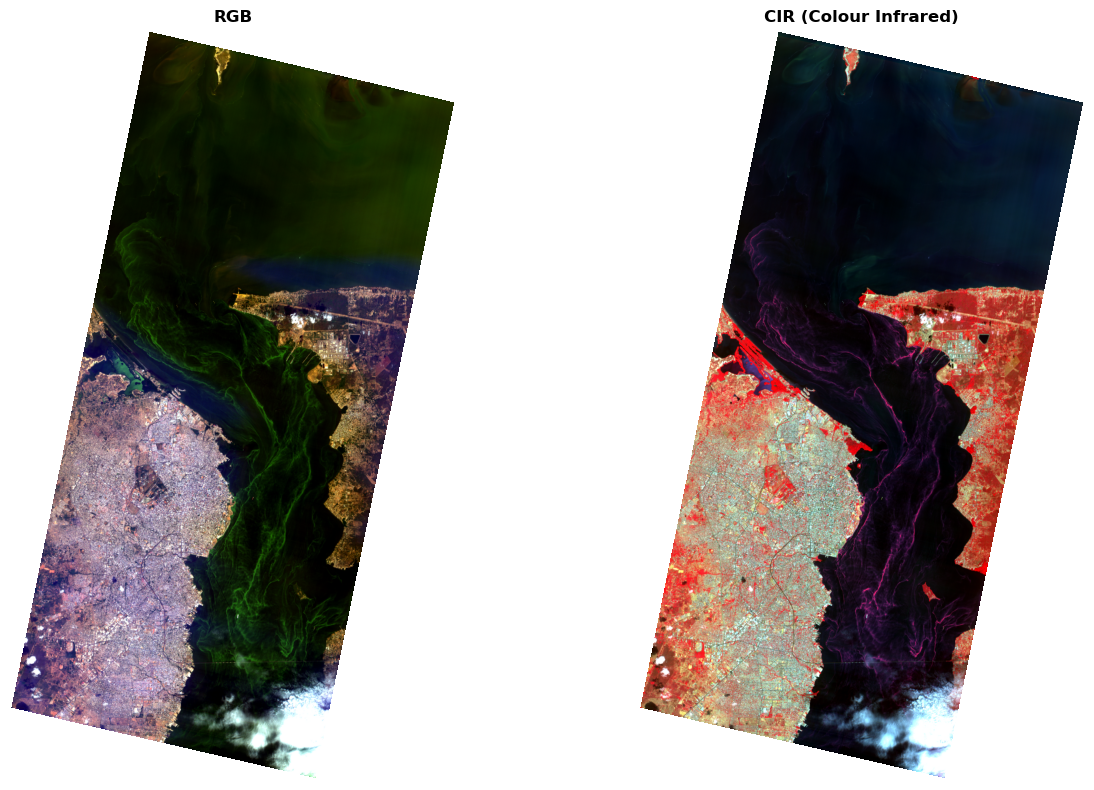

In [8]:
# Get bands for RGB and CIR
red_band = get_band(650)
green_band = get_band(550)
blue_band = get_band(450)
nir_band = get_band(800)


def normalize(array: np.ndarray) -> np.ndarray:
    """
    Stretch an image band to the 0–1 range for display.

    Values below the 2nd percentile and above the 98th percentile are clipped to reduce the influence of unusually dark or bright pixels.

    Args:
    array : np.ndarray
        A 2D image band containing reflectance values.

    Returns:
    np.ndarray
        The normalized image band with values between 0 and 1.
    """
    vmin = np.nanpercentile(array, 2)
    vmax = np.nanpercentile(array, 98)
    return np.clip((array - vmin) / (vmax - vmin), 0, 1)


# Normalize each band individually and stack into composites
rgb_display = np.dstack(
    [normalize(red_band), normalize(green_band), normalize(blue_band)]
)
cir_display = np.dstack(
    [normalize(nir_band), normalize(red_band), normalize(green_band)]
)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

axes[0].imshow(rgb_display)
axes[0].set_title("RGB", fontsize=12, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(cir_display)
axes[1].set_title("CIR (Colour Infrared)", fontsize=12, fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.show()

The RGB image gives us a natural colour view of the scene. The strait runs through the centre, with the city of Maracaibo visible on the left. The bright green swirling patterns in the water suggest some kind of biological or suspended material activity, possibly algae-related.

In the CIR image, vegetation on land appears bright red as expected. The algae-like features in the water show up as bright pink/magenta streaks. This is because whatever is causing those patterns appears to be reflecting NIR light, which is unusual for typical water and may suggest the presence of biological material.

These images give us a good starting point but can only tell us so much. To really dig into what's happening in the water, we'll use hyperspectral indices to map specific signals like turbidity and chlorophyll across the scene. Let's get started!

## The Indices

Here's an overview of each index we'll calculate and what it tells us about the water.

When choosing indices for a scene, a good starting point is to think about what you're trying to measure and what's physically happening in the water. For Lake Maracaibo, where algae blooms and turbidity are both known to be present, these indices can give us a clearer picture of the water's condition.

You can find a list of indices in the 
[Wyvern Hyperspectral Index Library](https://knowledge.wyvern.space/hyperspectral_library).

**NDWI (Normalized Difference Water Index)** `(green - nir) / (green + nir)` (green: 550nm, NIR: 800nm) Uses the green and NIR bands to identify water. Water commonly has higher NDWI values than surrounding land because it absorbs strongly in the near-infrared. However, the exact values vary with scene conditions, atmospheric effects, turbidity, algae, and the selected bands. It's often used as a water mask before applying other water quality indices.

**NDTI (Normalized Difference Turbidity Index)** `(red - green) / (red + green)` (red: 650nm, green: 550nm) Uses the red and green bands to estimate turbidity. Turbid water carrying suspended sediment scatters more red light relative to green, so higher NDTI values indicate more turbid water.

**NDCI (Normalized Difference Chlorophyll Index)** `(red_edge - red) / (red_edge + red)` (red-edge: 712nm, red: 650nm) Uses the red-edge and red bands to detect chlorophyll-a in water. This is where hyperspectral imagery really shines. Dragonette's narrow bands give us coverage right at the wavelength where the chlorophyll signal is strongest.


## Getting our Bands

Now we can use our helper function to select the right bands for each water quality index. We just pass in the wavelength we need and it finds the closest available band automatically.

In [9]:
green = get_band(550)  # NDWI, NDTI
nir = get_band(800)  # NDWI
red = get_band(650)  # NDTI, NDCI
re = get_band(712)  # NDCI

Requested 550nm -- using 550nm
Requested 800nm -- using 799nm
Requested 650nm -- using 650nm
Requested 712nm -- using 712nm


## Calculating the Indices
Now we can calculate each index using NumPy. Each equation is applied across every pixel in the image at once — so no loops needed!

In [10]:
# Calculate each index across every pixel
ndwi = (green - nir) / (green + nir)
ndti = (red - green) / (red + green)
ndci = (re - red) / (re + red)

## NDWI: Mapping Water

Let's start by plotting NDWI across the full scene. This gives us a clear picture of where the water is — the first step before we start assessing what's in it.

Rather than hardcoding `vmin` and `vmax`, we'll use the 2nd and 98th percentiles of the data. This automatically clips out extreme outlier values at both ends and makes the variation across the scene much more visible.

NDWI minimum: -0.8316
NDWI maximum: 0.5510
NDWI 2nd percentile: -0.6154
NDWI 98th percentile: 0.1038


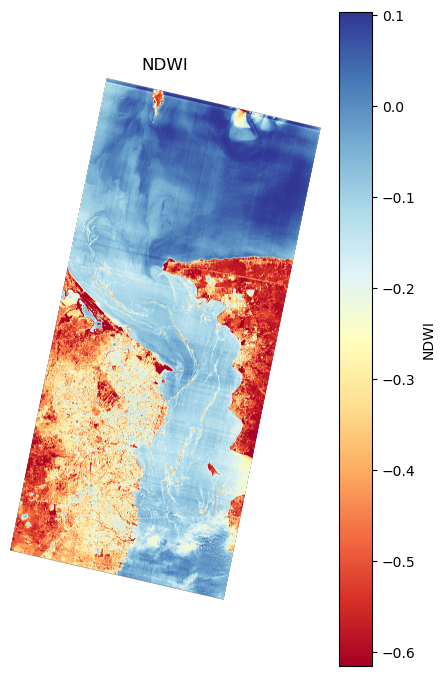

In [11]:
ndwi_vmin = np.nanpercentile(ndwi, 2)
ndwi_vmax = np.nanpercentile(ndwi, 98)

print(f"NDWI minimum: {np.nanmin(ndwi):.4f}")
print(f"NDWI maximum: {np.nanmax(ndwi):.4f}")
print(f"NDWI 2nd percentile: {ndwi_vmin:.4f}")
print(f"NDWI 98th percentile: {ndwi_vmax:.4f}")

plt.figure(figsize=(5, 8.5))
plt.imshow(ndwi, cmap="RdYlBu", vmin=ndwi_vmin, vmax=ndwi_vmax)
plt.colorbar(label="NDWI")
plt.title("NDWI")
plt.axis("off")
plt.show()

Blue areas are water, red areas are land. Within the water body you can see some areas showing lower NDWI values than the open water, possibly where surface conditions like algae are affecting the green and NIR reflectance differently from clear water.

### Water Mask
NDWI is commonly used as a water mask, but it struggles with this scene. Algae reflects both green and NIR light, which can push NDWI values lower than expected for water, or even become negative in heavily algae-covered areas. Using a simple NDWI threshold risks masking out exactly the water pixels we're most interested in and the algae-affected water is the whole reason we're here.

Instead, we'll use two masks combined:

- **A water polygon** manually drawn in QGIS following the shoreline of the scene, which cleanly separates water from land regardless of what's happening spectrally in the water.
- **Wyvern's QA_CLEAR_MASK**, a band included with every L2A product that flags whether each pixel is clear of cloud, haze, and shadow. A value of `1` means the pixel is clear and good to use, `0` means it's affected by atmospheric interference. This automatically excludes the cloudy pixels visible at the bottom of our scene.

Together these will give us a clean mask of clear, cloud-free water pixels.


In [12]:
from rasterio.features import geometry_mask

WATER_MASK_PATH = "water_mask.geojson"

# Load the water polygon drawn in QGIS, and extract geometries for raster masking
water_mask = gpd.read_file(WATER_MASK_PATH)
geometries = water_mask.geometry

# Load Wyvern's QA_CLEAR_MASK: 1 = clear pixel, 0 = cloud/haze/shadow
with rasterio.open(DATA_MASK_PATH) as data_mask_file:
    qa_clear = data_mask_file.read(1)

# Rasterize the water polygon to match the image dimensions
with rasterio.open(IMAGE_PATH) as image_file:
    water_polygon_mask = geometry_mask(
        geometries,
        transform=image_file.transform,
        invert=True,
        out_shape=(image_file.height, image_file.width),
    )

# Combine water polygon and QA clear mask and keep only clear water pixels
water_mask = water_polygon_mask & (qa_clear == 1)

Let's visualize the water mask to make sure it looks correct before applying it to our water quality indices.

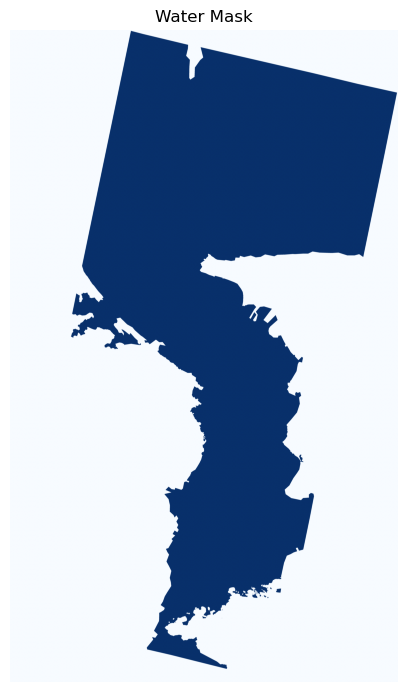

In [13]:
plt.figure(figsize=(5, 8.5))
plt.imshow(water_mask, cmap="Blues")
plt.title("Water Mask")
plt.axis("off")
plt.show()

### NDTI: Turbidity

NDTI uses the red and green bands to estimate turbidity. Higher values indicate more suspended sediment in the water column, while lower values suggest less turbidity. We calculated it earlier using:

`ndti = (red - green) / (red + green)`

For this scene we'd expect to see higher turbidity near the shoreline and in shallower areas where sediment is stirred up, and lower values in the deeper open water of the strait.

Let's check the value range before plotting. This helps us set `vmin` and `vmax` so the variation in the water is visible and doesn't get lost in the full -1 to 1 range.

In [14]:
# Apply the water mask to NDTI, excludes land pixels from the plot
ndti_masked = np.where(water_mask, ndti, np.nan)

# Check the value range to set colormap limits
print(f"Min: {np.nanmin(ndti_masked):.4f}")
print(f"Max: {np.nanmax(ndti_masked):.4f}")
print(f"2nd percentile: {np.nanpercentile(ndti_masked, 2):.4f}")
print(f"98th percentile: {np.nanpercentile(ndti_masked, 98):.4f}")

Min: -0.3290
Max: 0.3730
2nd percentile: -0.1936
98th percentile: 0.0174


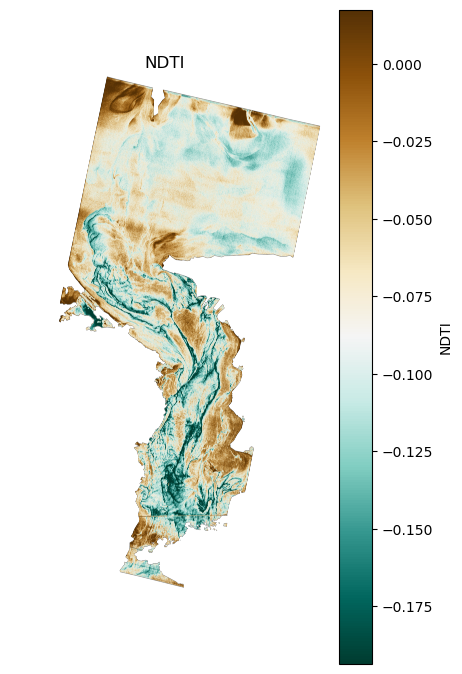

In [15]:
# Use percentiles to take out extreme values and improve contrast
vmin = np.nanpercentile(ndti_masked, 2)
vmax = np.nanpercentile(ndti_masked, 98)

plt.figure(figsize=(5, 8.5))
plt.imshow(ndti_masked, cmap="BrBG_r", vmin=vmin, vmax=vmax)
plt.colorbar(label="NDTI")
plt.title("NDTI")
plt.axis("off")
plt.show()

The NDTI map shows some really clear spatial patterns! Higher values (brown and tan) near the shorelines may reflect shallower areas close to the coast, not necessarily more turbid water.

However, the lower values (teal and green-blue) running through the centre of the strait are interesting. NDTI can't tell the difference between turbidity and other surface conditions, so those lower values might not just mean cleaner, less turbid water — there could be something else going on spectrally.

Based on what we've seen from the RGB visual, those lower values could reflect the influence of algae or other biological material.

### Highlighting Areas of High Turbidity

The original NDTI map shows the full range of turbidity values across the scene. However, this can make the most turbid areas harder to identify because lower and moderate values still occupy much of the colour scale.

To make the strongest turbidity patterns stand out, we'll display only the highest 20% of NDTI values within the water area.

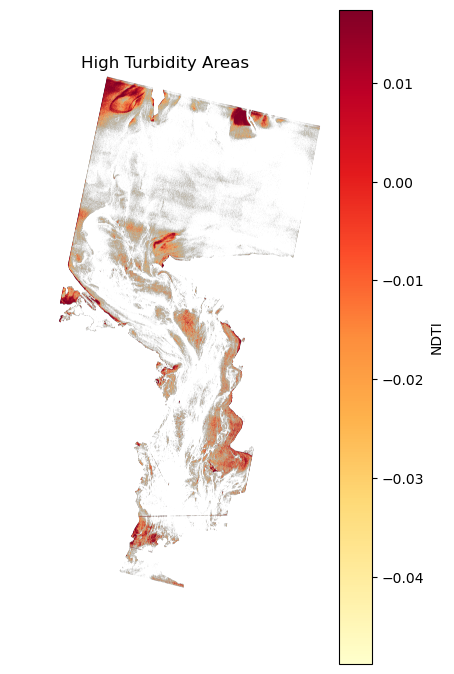

In [16]:
# Only show the highest NDTI values so high-turbidity areas stand out
threshold = np.nanpercentile(ndti_masked, 80)

# Hide pixels below the threshold
high_ndti = np.where(ndti_masked >= threshold, ndti_masked, np.nan)

# Scale the colour range using only the highlighted values
vmin = threshold
vmax = np.nanpercentile(ndti_masked, 98)

plt.figure(figsize=(5, 8.5))
plt.imshow(high_ndti, cmap="YlOrRd", vmin=vmin, vmax=vmax)
plt.colorbar(label="NDTI")
plt.title("High Turbidity Areas")
plt.axis("off")
plt.show()

Scaling the colormap this way lets the high-value areas stand out rather than blending into a gradient across the scene. The strongest signal shows up along the shorelines and in the shallower areas close to the coast, though as we noted, this doesn't necessarily mean more turbid water.

Let's focus on the lower signal in the open channel running through the centre. Something other than sediment might be influencing those pixels — algae absorbs red light and reflects green, which can push NDTI low in areas with significant biological surface cover. NDTI alone can't tell the difference. We'll look into this further with NDCI!

### NDCI: Chlorophyll

NDCI uses the red-edge and red bands to detect chlorophyll-a in water. We calculated it earlier using:

`ndci = (re - red) / (re + red)`

Hyperspectral imagery can be really helpful here because it can give us narrow bands across the visible and red-edge regions!  

Chlorophyll absorbs strongly in the blue and red parts of the spectrum, around ~440 nm and ~670 nm.

NDCI uses the contrast between the red absorption region and the red-edge region around ~700–720 nm, where reflectance increases due to scattering from algal and cellular structures. Higher NDCI values means a stronger chlorophyll signal in the water.

For this scene, if the lower NDTI values we saw in the channel are actually caused by algae, we'd expect to see higher NDCI values in those same areas.

Let's check the value range before plotting:

In [17]:
# Apply the water mask to NDCI
ndci_masked = np.where(water_mask, ndci, np.nan)

# Check the value range to set colormap limits
print(f"Min: {np.nanmin(ndci_masked):.4f}")
print(f"Max: {np.nanmax(ndci_masked):.4f}")
print(f"2nd percentile: {np.nanpercentile(ndci_masked, 2):.4f}")
print(f"98th percentile: {np.nanpercentile(ndci_masked, 98):.4f}")

Min: -0.1786
Max: 0.6252
2nd percentile: -0.0589
98th percentile: 0.3639


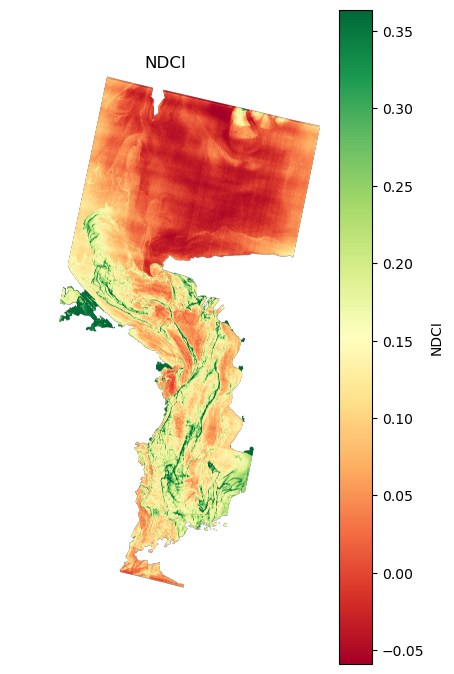

In [18]:
# Use percentiles to clip extreme values and improve contrast
vmin = np.nanpercentile(ndci_masked, 2)
vmax = np.nanpercentile(ndci_masked, 98)

plt.figure(figsize=(5, 8.5))
plt.imshow(ndci_masked, cmap="RdYlGn", vmin=vmin, vmax=vmax)
plt.colorbar(label="NDCI")
plt.title("NDCI")
plt.axis("off")
plt.show()

The NDCI map gives us a clearer picture. The bright green areas running through the strait line up exactly with the swirling patterns we saw in the RGB image. Higher NDCI values here mean elevated chlorophyll, and could point to increased algal activity.

This also helps make sense of what we saw in the NDTI map. Those lower turbidity values in the channel might not just mean cleaner water. Algae and other biological material can affect the red/green ratio too.

The open water in the upper portion of the scene shows lower NDCI values (red and orange), suggesting less chlorophyll which makes sense for more open, less nutrient-rich water.

This is a good example of why using multiple indices together gives you a much more complete picture of the water's condition than any single index on its own!

## Areas of Interest
Let's zoom into two specific areas to see what's going on in the water more closely: one where turbidity is the dominant signal, and one where chlorophyll is.

For each area we'll look at four views side by side: RGB and CIR for visual context, then NDTI and NDCI to see how the indices respond. Comparing them directly is a good way to build intuition for what each index is actually picking up and where they tell different stories about the water.

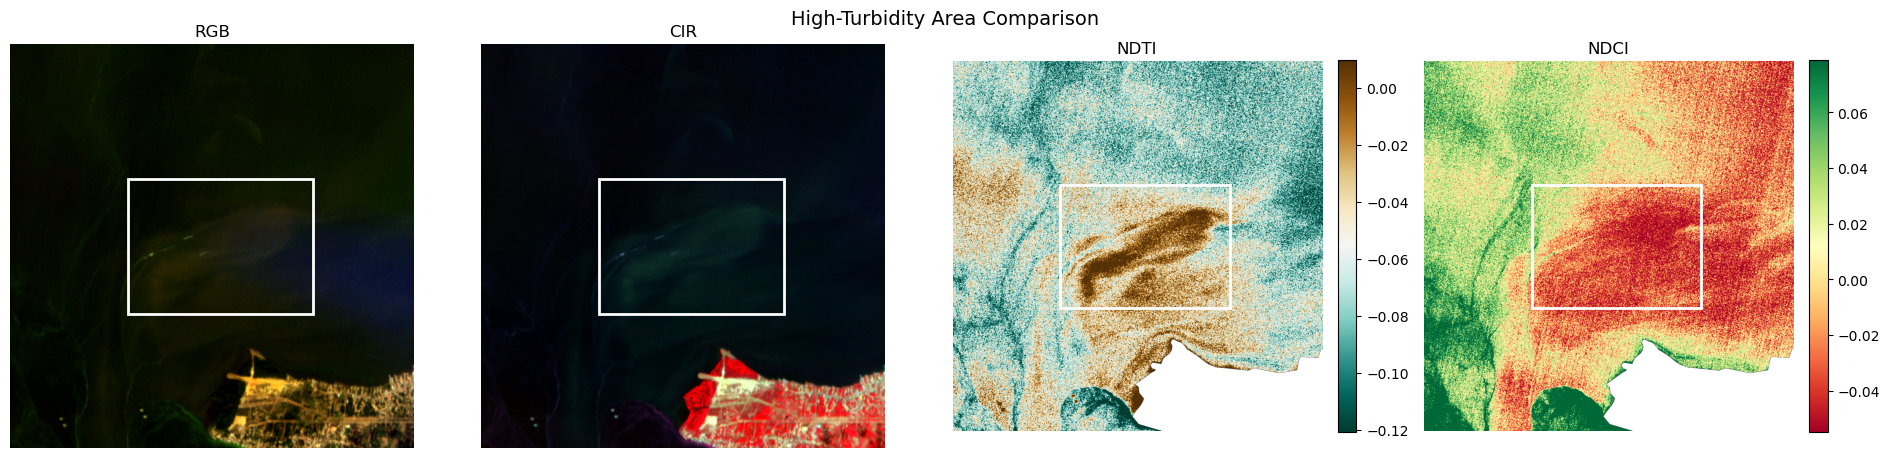

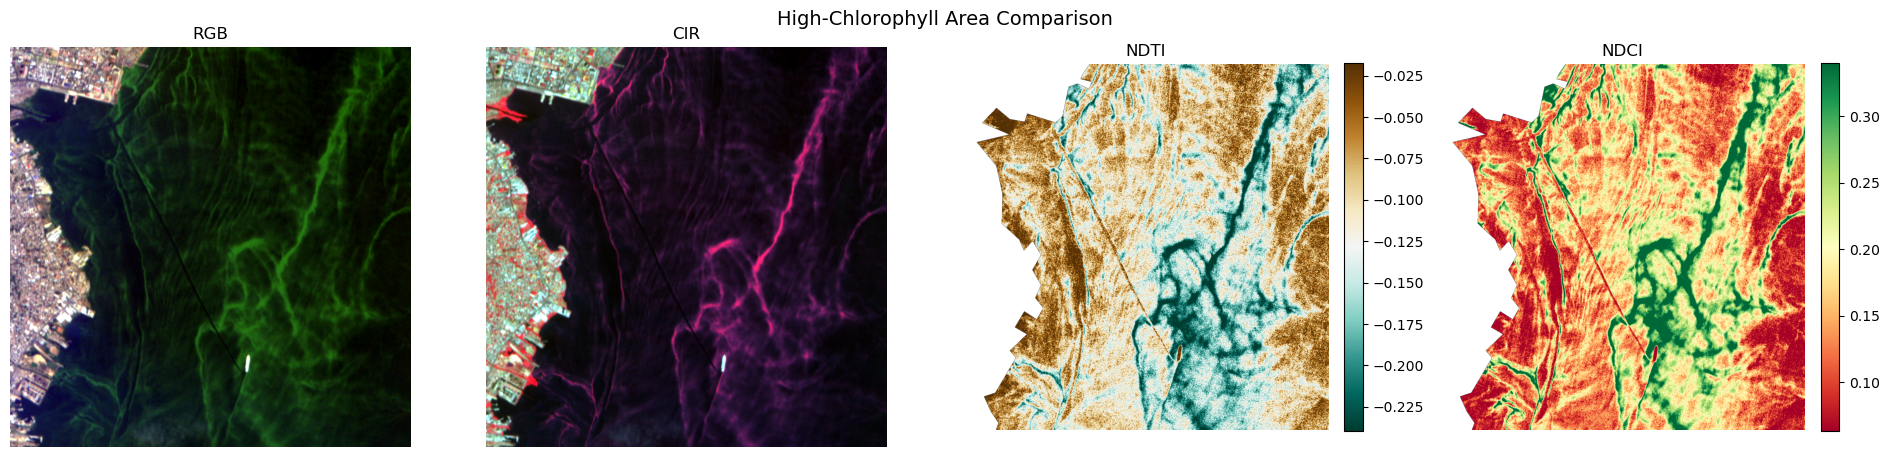

In [19]:
from matplotlib.patches import Rectangle

# High-turbidity crop bounds
turbidity_row_start = 2500
turbidity_row_end = 3700
turbidity_col_start = 2300
turbidity_col_end = 3500

# High-chlorophyll crop bounds
chlorophyll_row_start = 6800
chlorophyll_row_end = 8000
chlorophyll_col_start = 2300
chlorophyll_col_end = 3500


# Create high-turbidity crops
turbidity_rgb = rgb_display[
    turbidity_row_start:turbidity_row_end, turbidity_col_start:turbidity_col_end
]

turbidity_cir = cir_display[
    turbidity_row_start:turbidity_row_end, turbidity_col_start:turbidity_col_end
]

turbidity_ndti = ndti_masked[
    turbidity_row_start:turbidity_row_end, turbidity_col_start:turbidity_col_end
]

turbidity_ndci = ndci_masked[
    turbidity_row_start:turbidity_row_end, turbidity_col_start:turbidity_col_end
]


# Create high-chlorophyll crops
chlorophyll_rgb = rgb_display[
    chlorophyll_row_start:chlorophyll_row_end, chlorophyll_col_start:chlorophyll_col_end
]

chlorophyll_cir = cir_display[
    chlorophyll_row_start:chlorophyll_row_end, chlorophyll_col_start:chlorophyll_col_end
]

chlorophyll_ndti = ndti_masked[
    chlorophyll_row_start:chlorophyll_row_end, chlorophyll_col_start:chlorophyll_col_end
]

chlorophyll_ndci = ndci_masked[
    chlorophyll_row_start:chlorophyll_row_end, chlorophyll_col_start:chlorophyll_col_end
]


# Scale each area of interest using only the values inside that crop.
# NDTI uses a wider percentile range to make the turbidity patterns stand out.
# NDCI uses a slightly tighter range so the chlorophyll signal is visible without looking overly stretched.
turbidity_ndti_vmin = np.nanpercentile(turbidity_ndti, 2)
turbidity_ndti_vmax = np.nanpercentile(turbidity_ndti, 98)

turbidity_ndci_vmin = np.nanpercentile(turbidity_ndci, 5)
turbidity_ndci_vmax = np.nanpercentile(turbidity_ndci, 95)

chlorophyll_ndti_vmin = np.nanpercentile(chlorophyll_ndti, 2)
chlorophyll_ndti_vmax = np.nanpercentile(chlorophyll_ndti, 98)

chlorophyll_ndci_vmin = np.nanpercentile(chlorophyll_ndci, 5)
chlorophyll_ndci_vmax = np.nanpercentile(chlorophyll_ndci, 95)


# Box around the plume inside the high-turbidity crop
plume_box_col = 350
plume_box_row = 400
plume_box_width = 550
plume_box_height = 400


# Display high-turbidity comparison
fig, axes = plt.subplots(1, 4, figsize=(19, 6))

axes[0].imshow(turbidity_rgb)
axes[0].set_title("RGB")
axes[0].axis("off")

axes[1].imshow(turbidity_cir)
axes[1].set_title("CIR")
axes[1].axis("off")

ndti_plot = axes[2].imshow(
    turbidity_ndti, cmap="BrBG_r", vmin=turbidity_ndti_vmin, vmax=turbidity_ndti_vmax
)
axes[2].set_title("NDTI")
axes[2].axis("off")

ndci_plot = axes[3].imshow(
    turbidity_ndci, cmap="RdYlGn", vmin=turbidity_ndci_vmin, vmax=turbidity_ndci_vmax
)
axes[3].set_title("NDCI")
axes[3].axis("off")

# Add a white box around the plume in each high-turbidity panel
for ax in axes:
    ax.add_patch(
        Rectangle(
            (plume_box_col, plume_box_row),
            plume_box_width,
            plume_box_height,
            linewidth=2,
            edgecolor="white",
            facecolor="none",
        )
    )

fig.colorbar(ndti_plot, ax=axes[2], fraction=0.046, pad=0.04)
fig.colorbar(ndci_plot, ax=axes[3], fraction=0.046, pad=0.04)

fig.tight_layout()
fig.text(0.5, 0.87, "High-Turbidity Area Comparison", ha="center", fontsize=14)

plt.show()


# Add a little space before the second comparison
print("\n")


# Display high-chlorophyll comparison
fig, axes = plt.subplots(1, 4, figsize=(19, 6))

axes[0].imshow(chlorophyll_rgb)
axes[0].set_title("RGB")
axes[0].axis("off")

axes[1].imshow(chlorophyll_cir)
axes[1].set_title("CIR")
axes[1].axis("off")

ndti_plot = axes[2].imshow(
    chlorophyll_ndti,
    cmap="BrBG_r",
    vmin=chlorophyll_ndti_vmin,
    vmax=chlorophyll_ndti_vmax,
)
axes[2].set_title("NDTI")
axes[2].axis("off")

ndci_plot = axes[3].imshow(
    chlorophyll_ndci,
    cmap="RdYlGn",
    vmin=chlorophyll_ndci_vmin,
    vmax=chlorophyll_ndci_vmax,
)
axes[3].set_title("NDCI")
axes[3].axis("off")

fig.colorbar(ndti_plot, ax=axes[2], fraction=0.046, pad=0.04)
fig.colorbar(ndci_plot, ax=axes[3], fraction=0.046, pad=0.04)

fig.tight_layout()
fig.text(0.5, 0.87, "High-Chlorophyll Area Comparison", ha="center", fontsize=14)

plt.show()

### High-Turbidity Area

In the RGB image, there's a faint plume visible in the water that's quite easy to miss at first. The CIR adds a little more context, with a slightly different tone in that region hinting that something is going on spectrally, though it's still not obvious what.

NDTI is where it becomes clear. The plume lights up with a strong turbidity signal, confirming that whatever is in the water is scattering red light, which is consistent with suspended sediment. And when we check NDCI, chlorophyll is low across the whole area. So this isn't algae. It could be that something has physically disturbed the water here and stirred up sediment from below. A passing ship is a reasonable explanation, and there is evidence of possible vessel traffic in the RGB if you look closely.

### High-Chlorophyll Area

Here the RGB tells a much more obvious story straight away. The bright green swirling streaks are hard to miss. In CIR they show up as magenta, which tells us the surface is reflecting strongly in NIR. That's unusual for water and points toward biological material at the surface.

NDTI is strongly negative across the whole area, the opposite of the turbidity region. Low red reflectance relative to green is consistent with chlorophyll absorbing red light. And NDCI confirms it: the swirling patterns map almost perfectly onto high chlorophyll values. This is very good evidence of an algal bloom.

Together, these two areas are a great example of how combining indices lets us tell one water quality concern from another — sediment in one spot, an algal bloom in the other.

## Comparing Spectral Curves

So far, we've been looking at the scene through image displays and index maps. Another useful way to explore water quality with hyperspectral data is to look at the spectra directly. Each condition in the water has its own shape across wavelength, and plotting the curve makes that fingerprint easy to see.

In this section, we'll compare the reflectance curves from three points in the water: one in a high-turbidity area, one in a high-chlorophyll area, and one in clear open water. We'll sample a single representative pixel for each condition and plot its curve across Wyvern's 31 bands. The image below shows where each sample point sits within the scene.

This helps us connect the maps back to the underlying data. Instead of only seeing where an index is high or low, we can look at how each condition behaves across wavelength and see which parts of the spectrum are driving the patterns we observed.

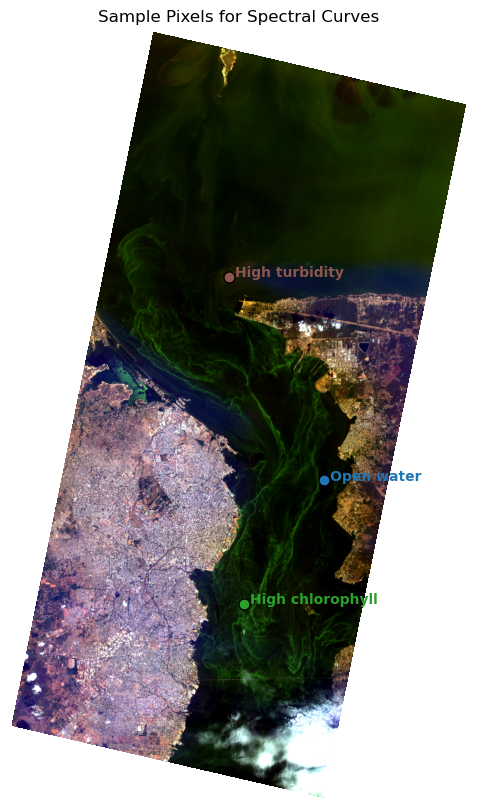

In [20]:
high_chlorophyll_pixel = (7392, 3009)
high_turbidity_pixel = (3181, 2815)
open_water_pixel = (5796, 4046)

# Show the selected pixels on the full RGB scene
fig, ax = plt.subplots(figsize=(8.5, 10))
ax.imshow(rgb_display)
ax.set_title("Sample Pixels for Spectral Curves")
ax.axis("off")

markers = [
    (high_turbidity_pixel, "High turbidity", "#8c564b"),
    (high_chlorophyll_pixel, "High chlorophyll", "#2ca02c"),
    (open_water_pixel, "Open water", "#1f77b4"),
]

for (row, col), label, color in markers:
    ax.plot(col, row, marker="o", markersize=8, markeredgecolor="black", color=color)
    ax.text(col + 80, row, label, color=color, fontsize=10, weight="bold")


plt.show()

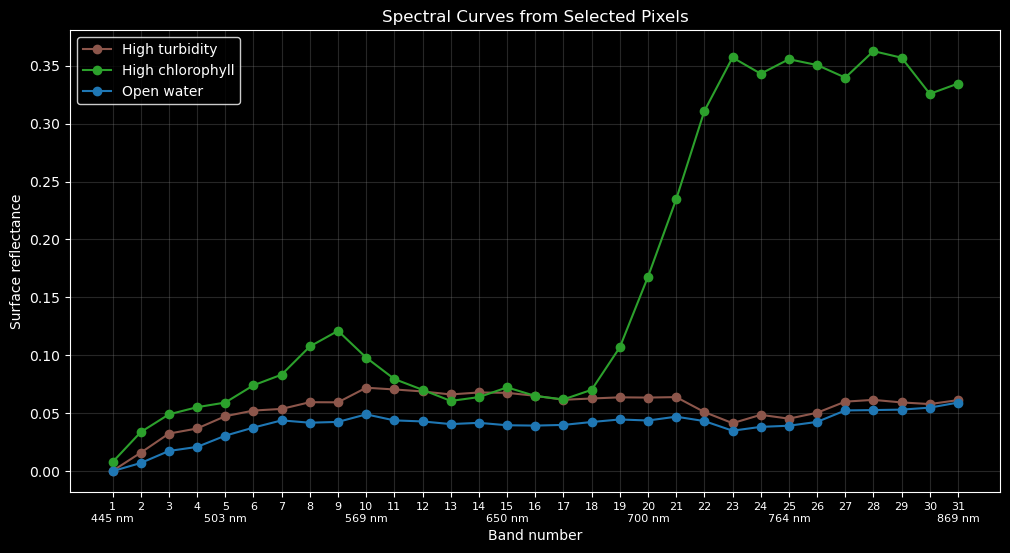

In [21]:
# Get wavelengths in band order for the x-axis
wavelengths = np.array(
    [
        wavelength
        for wavelength, _ in sorted(wavelength_map.items(), key=lambda item: item[1])
    ]
)
band_numbers = np.arange(1, len(wavelengths) + 1)

# Label only a few bands with their wavelength to keep the axis readable
labeled_bands = {1, 5, 10, 15, 20, 25, 31}
tick_labels = [
    f"{band}\n{wavelength} nm" if band in labeled_bands else str(band)
    for band, wavelength in zip(band_numbers, wavelengths)
]

# Grab each pixel's spectrum directly
high_turbidity_spectrum = image_array[
    :, high_turbidity_pixel[0], high_turbidity_pixel[1]
]
high_chlorophyll_spectrum = image_array[
    :, high_chlorophyll_pixel[0], high_chlorophyll_pixel[1]
]
open_water_spectrum = image_array[:, open_water_pixel[0], open_water_pixel[1]]

# Plot the spectral curves
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

ax.plot(
    band_numbers,
    high_turbidity_spectrum,
    marker="o",
    color="#8c564b",
    label="High turbidity",
)
ax.plot(
    band_numbers,
    high_chlorophyll_spectrum,
    marker="o",
    color="#2ca02c",
    label="High chlorophyll",
)
ax.plot(
    band_numbers, open_water_spectrum, marker="o", color="#1f77b4", label="Open water"
)

ax.set_xlabel("Band number", color="white")
ax.set_ylabel("Surface reflectance", color="white")
ax.set_title("Spectral Curves from Selected Pixels", color="white")
ax.set_xticks(band_numbers)
ax.set_xticklabels(tick_labels, fontsize=8)
ax.tick_params(colors="white")
for spine in ax.spines.values():
    spine.set_color("white")
ax.grid(True, color="gray", alpha=0.3)

legend = ax.legend(facecolor="black", edgecolor="white")
for text in legend.get_texts():
    text.set_color("white")

plt.show()

The high-chlorophyll pixel (green) peaks in the green band around 550nm, dips through the red where chlorophyll absorbs, then rises sharply starting around 700 nm, climbing far above the other two and staying high all the way through the near-infrared. That steep jump is the chlorophyll red-edge: chlorophyll absorbs red light but reflects strongly just past it, and it's the feature NDCI is built to detect. A strong red-edge like this points to a lot of chlorophyll material at the surface and is the signal you'd expect from dense vegetation or an algae-rich patch of water.

The high-turbidity pixel (brown) sits above open water through most of the visible range. That makes sense since suspended sediment scatters light broadly across the spectrum rather than at one specific wavelength, so turbid water is brighter overall in the visible. It doesn't show the red-edge jump: in the near-infrared it stays low and flat, close to open water. That contrast is the difference between a turbidity signal and a chlorophyll signal, and it's why NDTI looks at the red vs green balance while NDCI looks at the red-edge.

Open water (blue) is the lowest curve throughout and gives us a baseline. It stays low across the visible and has none of the red-edge rise we see in the bloom. Clear water absorbs more of the light that hits it, while the suspended sediment in turbid water scatters light more.

These spectra confirm that what NDTI and NDCI flagged really are different things happening in the water!

## Sharing Your Results

So far we've visualized the indices as maps inside the notebook. But if you want to share the results with someone who doesn't have Python, load them into QGIS, or feed them into another workflow, we can export them as a GeoJSON file. Here we'll do that with our NDCI results, turning the areas with the highest chlorophyll signal into a vector layer of polygons that can be used anywhere.

We'll treat the top 10% of NDCI values within the water mask as high-chlorophyll pixels, then use `rasterio.features.shapes()` to trace their edges into geographic polygons and save them as a GeoJSON using GeoPandas.

In [22]:
from rasterio.features import shapes
from shapely.geometry import shape

# Select the top 10% of NDCI values as high chlorophyll
threshold = np.nanpercentile(ndci_masked, 90)
high_chlorophyll_mask = np.where(ndci_masked >= threshold, 1, 0).astype(np.uint8)

# Get the image transform and CRS
with rasterio.open(IMAGE_PATH) as image_file:
    transform = image_file.transform
    crs = image_file.crs

# Trace pixels into polygons
high_chlorophyll_polygons = [
    shape(polygon_geometry)
    for polygon_geometry, pixel_value in shapes(
        high_chlorophyll_mask, transform=transform
    )
    if pixel_value == 1
]

# Save as GeoJSON in WGS84  so it loads correctly in QGIS and other GIS tools
gdf = gpd.GeoDataFrame(geometry=high_chlorophyll_polygons, crs=crs)
gdf.to_crs("EPSG:4326").to_file("maracaibo_high_chlorophyll.geojson", driver="GeoJSON")

print("Saved maracaibo_high_chlorophyll.geojson!")

Saved maracaibo_high_chlorophyll.geojson!


The GeoJSON file can now be dragged straight into QGIS and overlaid on a satellite basemap. The polygons trace the high-chlorophyll areas we identified from the NDCI map.

![High chlorophyll areas exported as GeoJSON and loaded into QGIS over a Google Satellite basemap.](maracaibo_high_chlorophyll_qgis.png)

*High chlorophyll areas exported as GeoJSON and loaded into QGIS over a Google Satellite basemap.*

## Other Packages

NumPy is the most straightforward tool for index calculations and what we've used throughout this tutorial, but there are several other Python packages worth knowing about!

### HyperCoast
[HyperCoast](https://hypercoast.org/) is a Python package for visualizing and analyzing hyperspectral data, with a focus on coastal and water applications — so it's a natural fit for water-quality work like this. It lets you view hyperspectral scenes, swap band combinations, pull out spectral signatures, and even explore your data in 3D. There's also a QGIS plugin if you'd rather work interactively with less code. Here's a [walkthrough for visualizing Wyvern open data](https://www.youtube.com/watch?v=BYrQdhz5k5o) to get you started. It's peer-reviewed through JOSS, and you can install it with `pip install hypercoast`.

### NumExpr
[NumExpr](https://numexpr.readthedocs.io/en/latest/) speeds up NumPy array operations by evaluating expressions in chunks and taking advantage of multiple CPU cores. For large images it can be significantly faster than plain NumPy. An NDWI calculation that would look like `(green - nir) / (green + nir)` in NumPy becomes `ne.evaluate("(green - nir) / (green + nir)")` in NumExpr — the equation is the same, just passed as a string.

### EarthPy
[EarthPy](https://earthpy.readthedocs.io/en/latest/api/earthpy.spatial.html#earthpy.spatial.normalized_diff) provides a `normalized_diff()` function which can be used to calculate simple two-band indices like NDWI and NDCI without writing the equation yourself.

### Xarray-Spatial
[Xarray-Spatial](https://xarray-spatial.org/user_guide/multispectral.html) has built-in functions for calculating a number of useful indices using Xarray arrays, which can be handy for working with larger datasets.

### Awesome Spectral Indices (Spyndex)
David Montero Loaiza's [Awesome Spectral Indices](https://github.com/awesome-spectral-indices/awesome-spectral-indices) project contains a standardised database of spectral indices. For Python, [Spyndex](https://github.com/awesome-spectral-indices/spyndex) lets you pull equations directly from the database rather than writing them yourself — worth exploring if you plan to calculate many different indices regularly.

## What's Next?

In this tutorial we used three indices to explore water quality patterns in a single scene. But this is just a starting point — there are many more indices in the [Wyvern Hyperspectral Index Library](https://knowledge.wyvern.space/hyperspectral_library) 
worth exploring.

A few ideas to take this further:

- Try applying these indices to a different Wyvern scene and compare the results. Browse available scenes on the [Wyvern Open Data Program](https://opendata.wyvern.space)
- Look into the [Visualizing Spectra & Plotting](https://knowledge.wyvern.space/docs/tutorials/python/visualizing_spectra) 
tutorials for more ways to explore hyperspectral data in Python